In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

In [2]:
DATA_PATH = "data/results/final_data.csv"
df = pd.read_csv(DATA_PATH)

# Drop name column
df.drop(columns=["name", "longitude", "latitude"], inplace=True)

df.head()

,ndvi,discharge,ndwi,precipitation,slope_degrees,ndbi,mndwi,label
0,0.066701,55.034,0.073592,3.131967,7.622371,0.323883,-0.254714,1
1,0.731389,1.290,-0.653989,5.849727,10.982635,-0.266065,-0.480811,1
2,0.042219,0.316,0.080037,6.014481,14.731374,0.154665,-0.044599,1
3,0.320390,116.366,-0.316262,1.683060,2.037220,0.028663,-0.345646,1
4,0.399828,36.573,-0.378034,1.739071,2.888671,-0.077216,-0.318782,1


In [3]:
desc = df.describe()

df.describe()

,ndvi,discharge,ndwi,precipitation,slope_degrees,ndbi,mndwi,label
count,7813.000000,7969.000000,6425.000000,7970.000000,7968.000000,6426.000000,6422.000000,7975.000000
mean,0.503987,35.025917,-0.452509,2.767513,5.126560,-0.114915,-0.380328,0.373041
std,0.234376,226.243491,0.237202,1.706450,5.229205,0.159776,0.175901,0.483643
min,-0.484026,0.000000,-0.814431,0.009290,0.000000,-0.904679,-0.664737,0.000000
25%,0.349148,0.771000,-0.629569,1.696311,1.409021,-0.237277,-0.491178,0.000000
50%,0.569224,2.161000,-0.530650,2.190984,2.980839,-0.131647,-0.430031,0.000000
75%,0.693333,6.204000,-0.329938,3.492691,7.415234,-0.002311,-0.327660,1.000000
max,0.908746,8228.332000,0.812579,12.417486,31.816454,0.722592,0.970019,1.000000


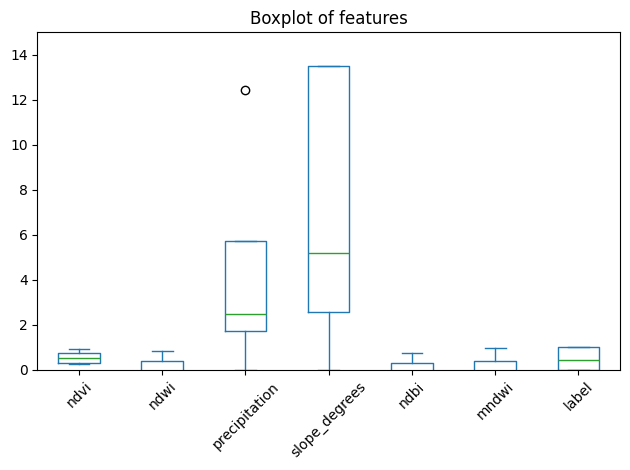

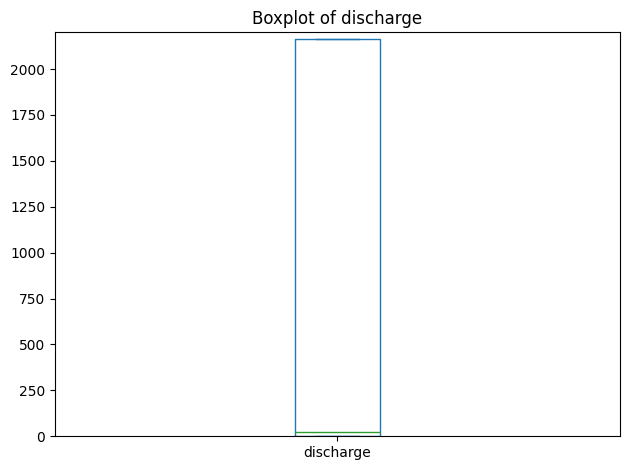

In [15]:
desc.drop(columns=["discharge"]).plot.box()
plt.title('Boxplot of features')
plt.xticks(rotation=45)
plt.ylim(top=15, bottom=0)
plt.tight_layout()
plt.show()

desc["discharge"].plot.box()
plt.title('Boxplot of discharge')
plt.ylim(top=2200, bottom=0)
plt.tight_layout()
plt.show()

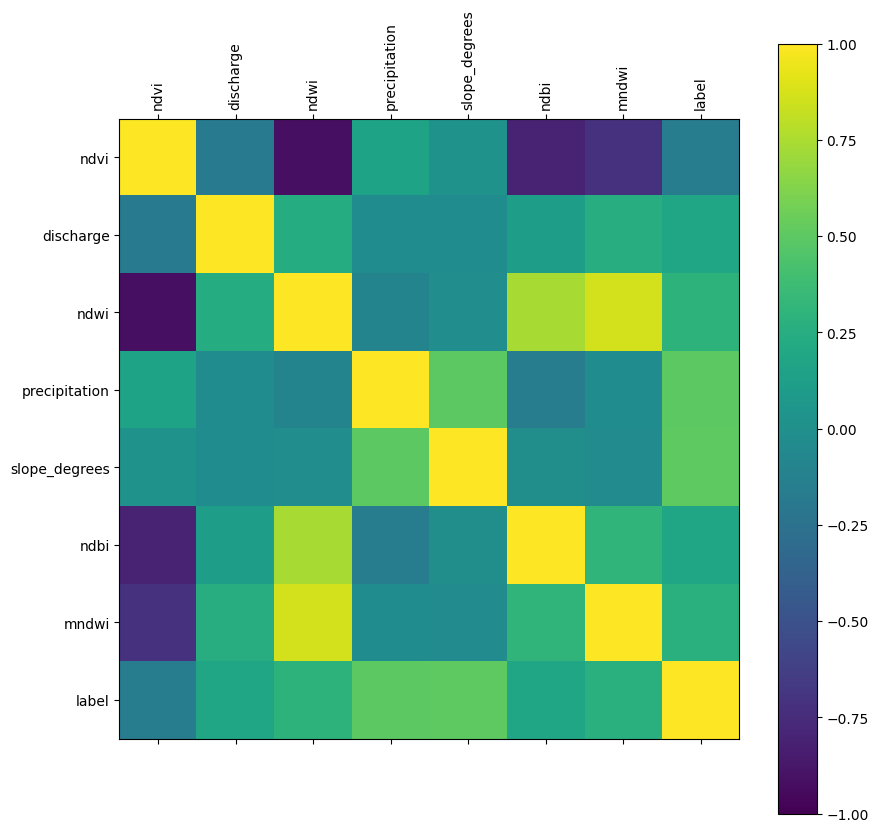

In [5]:
corr = df.corr(method='pearson')

fig = plt.figure(figsize=(10,10))

# 111: 1x1 grid, first subplot
ax = fig.add_subplot(111)

# normalize data using vmin, vmax
cax = ax.matshow(corr, vmin=-1, vmax=1)

# add a colorbar to a plot.
fig.colorbar(cax)

# define ticks to match the number of columns
ticks = np.arange(len(df.columns))

# set x and y tick marks
ax.set_xticks(ticks)
ax.set_yticks(ticks)

# set x and y tick labels
ax.set_xticklabels(df.columns, rotation=90)
ax.set_yticklabels(df.columns)

# draw a matrix using the correlations data
plt.show()